# Notebook 01 — Comprensión de los Datos (CRISP-DM Fase 2)

**Proyecto:** Clasificación automática de calidad de frutas
**Curso:** Algoritmos y Programación III — ICESI 2026-1
**Fase CRISP-DM:** 2. Comprensión de los datos

## Objetivos

1. Describir el origen y volumen del dataset multi-fruta (6 especies × 3 calidades = 18 clases).
2. Caracterizar la distribución de clases y cuantificar el desbalanceo.
3. Analizar la heterogeneidad de tamaño y aspecto de las imágenes.
4. Explorar diferencias cromáticas (HSV) entre niveles de calidad.
5. Detectar imágenes potencialmente problemáticas (outliers de tamaño, posibles duplicados).
6. Producir figuras vectoriales (SVG) y hallazgos que alimenten el informe IEEE.

## Salidas esperadas

- Figuras SVG en `outputs/figures/eda/`.
- Resumen narrativo en `outputs/eda_report.md`.

## Ética y privacidad (PI1)

El dataset combina imágenes recolectadas por estudiantes del curso. Solo se conservan **fotos de frutas individuales sobre fondos simples**; no se procesan rostros, personas ni metadatos personales (EXIF GPS). Las clases son auto-asignadas por el grupo y se documentan explícitamente para garantizar trazabilidad.


In [1]:
# Setup: imports, rutas y paleta de colores reproducible
from __future__ import annotations

import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

warnings.filterwarnings("ignore", category=UserWarning)

# Rutas relativas a la raíz del repo (este notebook vive en notebooks/)
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

MANIFEST_PATH = REPO_ROOT / "data" / "annotations" / "manifest.csv"
FIG_DIR = REPO_ROOT / "outputs" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Convenciones de figura para informe IEEE (vectorial)
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.format": "svg",
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
sns.set_style("whitegrid")

# Paleta consistente para fruta y calidad
FRUITS = ["Apple", "Banana", "Guava", "Lime", "Orange", "Pomegranate"]
QUALITIES = ["Good", "Regular", "Bad"]
QUALITY_COLORS = {"Good": "#2ca02c", "Regular": "#ff7f0e", "Bad": "#d62728"}
FRUIT_COLORS = dict(zip(FRUITS, sns.color_palette("tab10", n_colors=6)))

print(f"Repo root: {REPO_ROOT}")
print(f"Manifest:  {MANIFEST_PATH}")
print(f"Figuras:   {FIG_DIR}")


Repo root: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal
Manifest:  C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\data\annotations\manifest.csv
Figuras:   C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\outputs\figures\eda


## 1. Carga del manifest

El manifest CSV contiene una fila por imagen con: ruta relativa al repo, fruta, calidad, etiqueta combinada `class`, fuente (recolectada o kaggle) y dimensiones (`width`, `height`).


In [2]:
df = pd.read_csv(MANIFEST_PATH)
print(f"Filas: {len(df):,}  |  Columnas: {list(df.columns)}")
print(f"Fuentes presentes: {df['source'].value_counts().to_dict()}")
df.head()

Filas: 9,515  |  Columnas: ['path', 'fruit', 'quality', 'class', 'source', 'width', 'height']
Fuentes presentes: {'recolectada': 9515}


,path,fruit,quality,class,source,width,height
0,Fruits/Good Quality_Fruits/Apple_Good/20260529...,Apple,Good,Apple_Good,recolectada,2870,2888
1,Fruits/Good Quality_Fruits/Apple_Good/20260529...,Apple,Good,Apple_Good,recolectada,2740,2722
2,Fruits/Good Quality_Fruits/Apple_Good/20260529...,Apple,Good,Apple_Good,recolectada,3024,3024
3,Fruits/Good Quality_Fruits/Apple_Good/20260529...,Apple,Good,Apple_Good,recolectada,2755,2777
4,Fruits/Good Quality_Fruits/Apple_Good/20260529...,Apple,Good,Apple_Good,recolectada,2651,2845


### 1.1 Resumen numérico

- Conteo total de imágenes y por fuente.
- Tipo de cada columna y valores faltantes.


In [3]:
print(f"Total imágenes: {len(df):,}")
print(f"\nFrutas únicas:    {sorted(df['fruit'].unique())}")
print(f"Calidades únicas: {sorted(df['quality'].unique())}")
print(f"Clases únicas:    {df['class'].nunique()} (esperado: 18)")
print(f"\nValores faltantes por columna:")
print(df.isna().sum())

Total imágenes: 9,515

Frutas únicas:    ['Apple', 'Banana', 'Guava', 'Lime', 'Orange', 'Pomegranate']
Calidades únicas: ['Bad', 'Good', 'Regular']
Clases únicas:    18 (esperado: 18)

Valores faltantes por columna:
path       0
fruit      0
quality    0
class      0
source     0
width      0
height     0
dtype: int64


## 2. Distribución de las 18 clases

Visualizamos cuántas imágenes hay por cada combinación `Fruta_Calidad`. Esto permite identificar clases minoritarias que pueden requerir tratamiento especial (class_weight, augmentation, sub/oversampling).


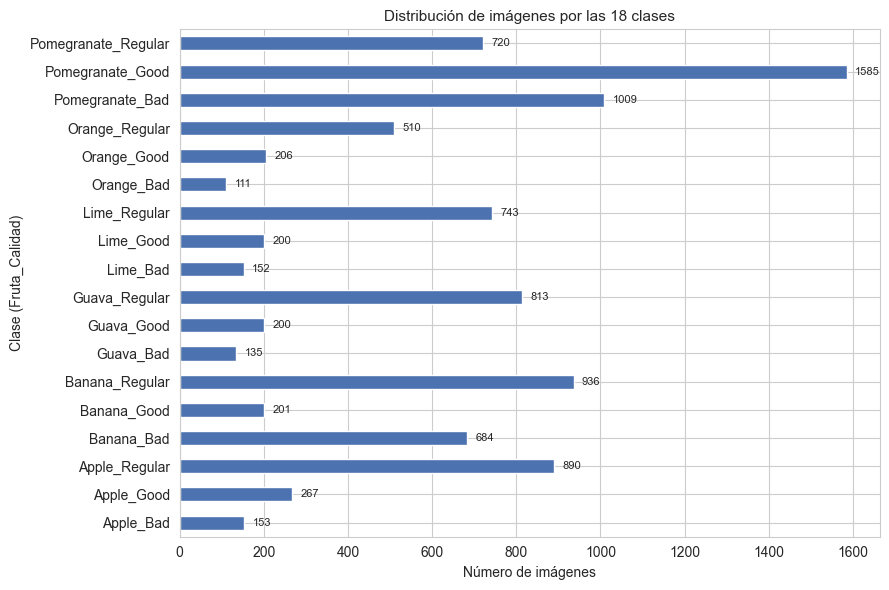


Clase mayoritaria: Pomegranate_Good (1,585 imgs)
Clase minoritaria: Orange_Bad (111 imgs)
Razón mayor/menor (Imbalance Ratio): 14.3


In [4]:
class_counts = df["class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 6))
class_counts.plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Número de imágenes")
ax.set_ylabel("Clase (Fruta_Calidad)")
ax.set_title("Distribución de imágenes por las 18 clases")
for i, v in enumerate(class_counts.values):
    ax.text(v + 20, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribucion_18_clases.svg")
plt.show()
print(f"\nClase mayoritaria: {class_counts.idxmax()} ({class_counts.max():,} imgs)")
print(f"Clase minoritaria: {class_counts.idxmin()} ({class_counts.min():,} imgs)")
print(f"Razón mayor/menor (Imbalance Ratio): {class_counts.max() / class_counts.min():.1f}")

### 2.1 Tabla cruzada fruta × calidad (heatmap)

El heatmap revela patrones específicos: por ejemplo, qué frutas tienen muchas imágenes "Regular" pero pocas "Bad", o viceversa.


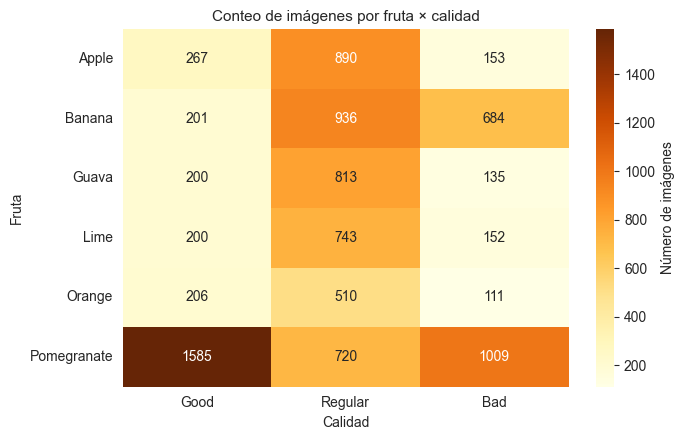


Tabla cruzada:
quality      Good  Regular   Bad
fruit                           
Apple         267      890   153
Banana        201      936   684
Guava         200      813   135
Lime          200      743   152
Orange        206      510   111
Pomegranate  1585      720  1009

Totales por fruta:    {'Apple': 1310, 'Banana': 1821, 'Guava': 1148, 'Lime': 1095, 'Orange': 827, 'Pomegranate': 3314}
Totales por calidad:  {'Good': 2659, 'Regular': 4612, 'Bad': 2244}


In [5]:
cross = pd.crosstab(df["fruit"], df["quality"])[QUALITIES]  # ordenar columnas

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(
    cross, annot=True, fmt="d", cmap="YlOrBr", ax=ax,
    cbar_kws={"label": "Número de imágenes"},
)
ax.set_title("Conteo de imágenes por fruta × calidad")
ax.set_xlabel("Calidad")
ax.set_ylabel("Fruta")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_heatmap_fruta_calidad.svg")
plt.show()
print("\nTabla cruzada:")
print(cross)
print(f"\nTotales por fruta:    {cross.sum(axis=1).to_dict()}")
print(f"Totales por calidad:  {cross.sum(axis=0).to_dict()}")

### 2.2 Métricas de desbalanceo

Cuantificamos el desbalanceo con tres indicadores:

- **Imbalance Ratio (IR):** $IR = \frac{n_{max}}{n_{min}}$. Cuanto mayor que 1, peor el desbalanceo.
- **Entropía normalizada:** $\hat{H} = -\frac{1}{\log K} \sum_k p_k \log p_k$, con $p_k = n_k / N$. Un valor de 1.0 indica distribución perfectamente uniforme.
- **Coeficiente de variación:** $CV = \sigma / \mu$ de los conteos. Útil como medida complementaria.


K (clases):             18
N (imágenes):           9,515
Imbalance Ratio:        14.28   (1 = perfecto, ∞ = peor)
Entropía normalizada:   0.903   (1 = uniforme)
Coef. de variación:     0.79   (0 = uniforme)


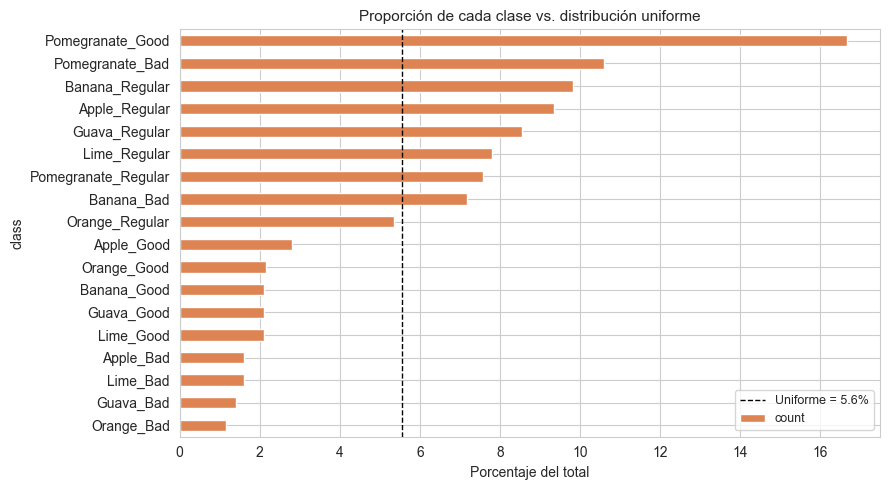

In [6]:
counts = df["class"].value_counts()
K = len(counts)
N = counts.sum()
p = counts / N

IR = counts.max() / counts.min()
H_norm = -(p * np.log(p)).sum() / np.log(K)
CV = counts.std() / counts.mean()

print(f"K (clases):             {K}")
print(f"N (imágenes):           {N:,}")
print(f"Imbalance Ratio:        {IR:.2f}   (1 = perfecto, ∞ = peor)")
print(f"Entropía normalizada:   {H_norm:.3f}   (1 = uniforme)")
print(f"Coef. de variación:     {CV:.2f}   (0 = uniforme)")

# Visual: porcentaje por clase, ordenado
fig, ax = plt.subplots(figsize=(9, 5))
(p.sort_values() * 100).plot(kind="barh", ax=ax, color="#dd8452")
ax.axvline(100 / K, ls="--", color="black", lw=1, label=f"Uniforme = {100/K:.1f}%")
ax.set_xlabel("Porcentaje del total")
ax.set_title("Proporción de cada clase vs. distribución uniforme")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_porcentaje_vs_uniforme.svg")
plt.show()

## 3. Análisis de tamaños de imagen

Las imágenes provienen de cámaras de celular y otros dispositivos. Esperamos heterogeneidad. Esto influye en la elección del tamaño de redimensionamiento para el pipeline de modelado.


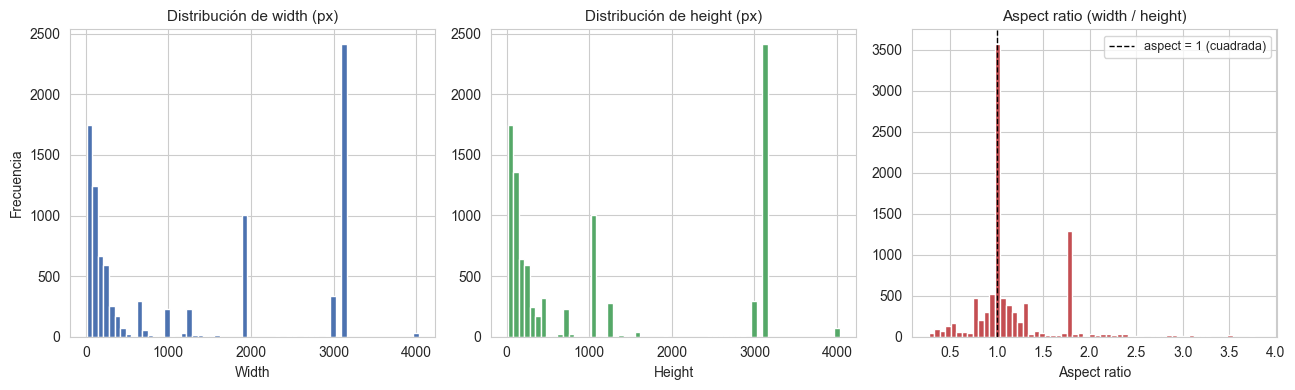


Estadísticas de tamaño:
        width  height
count  9515.0  9515.0
mean   1286.4  1191.2
std    1308.2  1305.9
min      13.0    12.0
25%     103.0   100.0
50%     495.0   434.0
75%    3120.0  3120.0
max    4032.0  4032.0

Aspect ratio - mediana: 1.00, p5-p95: (0.56, 1.85)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(df["width"], bins=60, color="#4c72b0", edgecolor="white")
axes[0].set_title("Distribución de width (px)")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df["height"], bins=60, color="#55a868", edgecolor="white")
axes[1].set_title("Distribución de height (px)")
axes[1].set_xlabel("Height")

aspect = df["width"] / df["height"]
axes[2].hist(aspect, bins=60, color="#c44e52", edgecolor="white")
axes[2].axvline(1.0, ls="--", color="black", lw=1, label="aspect = 1 (cuadrada)")
axes[2].set_title("Aspect ratio (width / height)")
axes[2].set_xlabel("Aspect ratio")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_size_distributions.svg")
plt.show()

print("\nEstadísticas de tamaño:")
print(df[["width", "height"]].describe().round(1))
print(f"\nAspect ratio - mediana: {aspect.median():.2f}, p5-p95: ({aspect.quantile(0.05):.2f}, {aspect.quantile(0.95):.2f})")

### 3.1 Imágenes outlier por tamaño

Identificamos imágenes anómalamente pequeñas (probablemente corruptas o thumbnails) o anómalamente grandes (que pueden ralentizar el preprocesamiento).


In [8]:
# Pequeñas: width o height < 100 px (umbral conservador)
SMALL = 100
small_df = df[(df["width"] < SMALL) | (df["height"] < SMALL)]
print(f"Imágenes con width o height < {SMALL} px: {len(small_df)}")
if len(small_df):
    print(small_df[["path", "class", "width", "height"]].head(10).to_string(index=False))

# Grandes: > 3000 px en algún lado
LARGE = 3000
large_df = df[(df["width"] > LARGE) | (df["height"] > LARGE)]
print(f"\nImágenes con width o height > {LARGE} px: {len(large_df)}")
if len(large_df):
    print(large_df["class"].value_counts().head(10).to_string())

Imágenes con width o height < 100 px: 2562
                                                           path         class  width  height
    Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001.jpg Apple_Regular     50      64
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_000.jpg Apple_Regular     64      50
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_001.jpg Apple_Regular     50      64
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_002.jpg Apple_Regular     64      50
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_003.jpg Apple_Regular     82      76
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_004.jpg Apple_Regular     50      64
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_005.jpg Apple_Regular     50      64
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_006.jpg Apple_Regular     26      32
Fruits/Regular Quality_Fruits/Apple_Regular/manzana_001_007.jpg Apple_Regular     25      32
Fruits/Regular Quality_Frui

## 4. Muestras visuales por clase

Grid 6 frutas × 3 calidades: una imagen aleatoria de cada combinación. Útil para confirmar que las etiquetas son consistentes con lo que se ve.


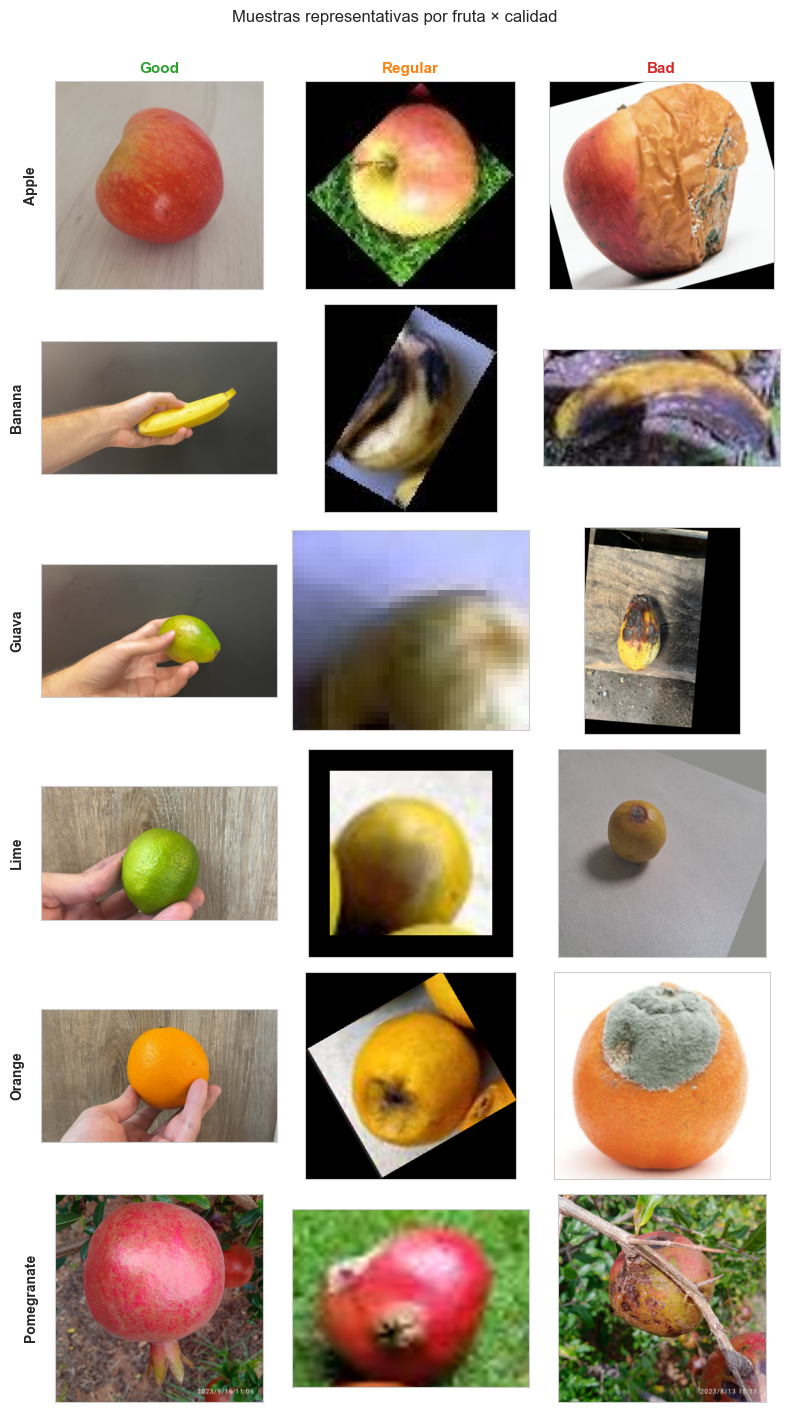

In [9]:
rng = np.random.default_rng(seed=42)

fig, axes = plt.subplots(len(FRUITS), len(QUALITIES), figsize=(8, 14))
for i, fruit in enumerate(FRUITS):
    for j, quality in enumerate(QUALITIES):
        ax = axes[i, j]
        subset = df[(df["fruit"] == fruit) & (df["quality"] == quality)]
        if len(subset) == 0:
            ax.text(0.5, 0.5, "vacío", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([])
            continue
        row = subset.iloc[rng.integers(0, len(subset))]
        img_path = REPO_ROOT / row["path"]
        try:
            img = Image.open(img_path).convert("RGB")
            img.thumbnail((300, 300))  # downscale para visualización
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"err\n{e}", ha="center", va="center", fontsize=6)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(quality, color=QUALITY_COLORS[quality], fontweight="bold")
        if j == 0:
            ax.set_ylabel(fruit, rotation=90, labelpad=12, fontweight="bold")

plt.suptitle("Muestras representativas por fruta × calidad", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_muestras_grid.svg")
plt.show()

## 5. Análisis cromático (HSV)

El espacio HSV separa color (H), pureza (S) e iluminación (V). En la detección visual de calidad:

- **H (Hue)** discrimina especies (amarillo → banano, naranja → naranja, rojo → manzana/granada).
- **S (Saturation)** suele caer en frutas magulladas o podridas (colores apagados).
- **V (Value)** captura iluminación; varía con condiciones de captura más que con calidad.

Calculamos el histograma promedio de H, S y V para una **muestra de hasta 60 imágenes por clase** (compromiso entre representatividad y tiempo).


In [10]:
def hsv_avg_histogram(paths, bins_h=36, bins_sv=32):
    '''Promedia histogramas H, S, V sobre una lista de rutas.'''
    h_hist = np.zeros(bins_h)
    s_hist = np.zeros(bins_sv)
    v_hist = np.zeros(bins_sv)
    n_ok = 0
    for p in paths:
        try:
            img = cv2.imread(str(p))
            if img is None:
                continue
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            h_hist += np.histogram(hsv[..., 0], bins=bins_h, range=(0, 180))[0]
            s_hist += np.histogram(hsv[..., 1], bins=bins_sv, range=(0, 256))[0]
            v_hist += np.histogram(hsv[..., 2], bins=bins_sv, range=(0, 256))[0]
            n_ok += 1
        except Exception:
            continue
    if n_ok == 0:
        return None
    return (h_hist / n_ok, s_hist / n_ok, v_hist / n_ok, n_ok)


SAMPLE_PER_CLASS = 60
rng = np.random.default_rng(42)
hsv_avg = {}
for cls in sorted(df["class"].unique()):
    sub = df[df["class"] == cls]
    sample = sub.sample(min(SAMPLE_PER_CLASS, len(sub)), random_state=42)
    paths = [REPO_ROOT / p for p in sample["path"]]
    out = hsv_avg_histogram(paths)
    if out:
        hsv_avg[cls] = out

print(f"Histogramas HSV calculados para {len(hsv_avg)}/18 clases (muestra de hasta {SAMPLE_PER_CLASS} imgs por clase)")

Histogramas HSV calculados para 18/18 clases (muestra de hasta 60 imgs por clase)


### 5.1 Comparación Good vs Regular vs Bad para una fruta

Comparamos los histogramas HSV promedio entre las tres calidades de **manzana** (Apple_Good, Apple_Regular, Apple_Bad). El razonamiento se extiende a las otras especies.


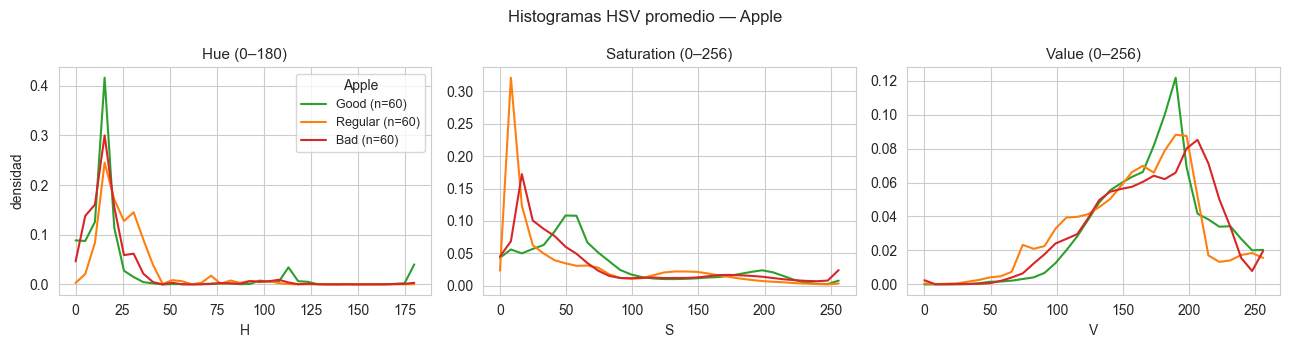

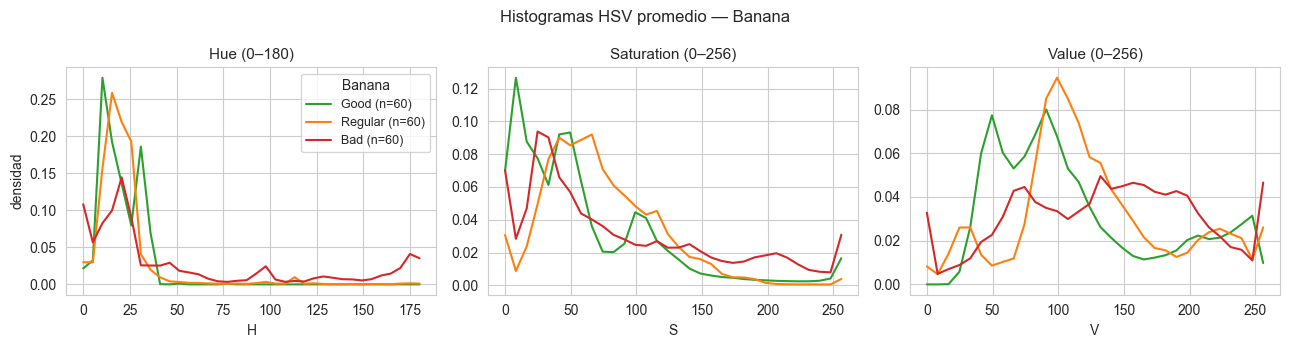

In [11]:
def plot_hsv_for_fruit(fruit_name: str, save_name: str):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for quality in QUALITIES:
        key = f"{fruit_name}_{quality}"
        if key not in hsv_avg:
            continue
        h, s, v, n = hsv_avg[key]
        c = QUALITY_COLORS[quality]
        axes[0].plot(np.linspace(0, 180, len(h)), h / h.sum(), label=f"{quality} (n={n})", color=c)
        axes[1].plot(np.linspace(0, 256, len(s)), s / s.sum(), color=c)
        axes[2].plot(np.linspace(0, 256, len(v)), v / v.sum(), color=c)
    axes[0].set_title("Hue (0–180)"); axes[0].set_xlabel("H"); axes[0].set_ylabel("densidad")
    axes[1].set_title("Saturation (0–256)"); axes[1].set_xlabel("S")
    axes[2].set_title("Value (0–256)"); axes[2].set_xlabel("V")
    axes[0].legend(title=fruit_name)
    plt.suptitle(f"Histogramas HSV promedio — {fruit_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / save_name)
    plt.show()

plot_hsv_for_fruit("Apple", "06_hsv_apple.svg")
plot_hsv_for_fruit("Banana", "07_hsv_banana.svg")

### 5.2 Hue promedio por clase

Una sola figura compacta: para cada clase, el valor medio de H (color dominante) y la mediana de S (pureza). Ayuda a ver si calidades distintas de una misma fruta se diferencian cromáticamente de forma consistente.


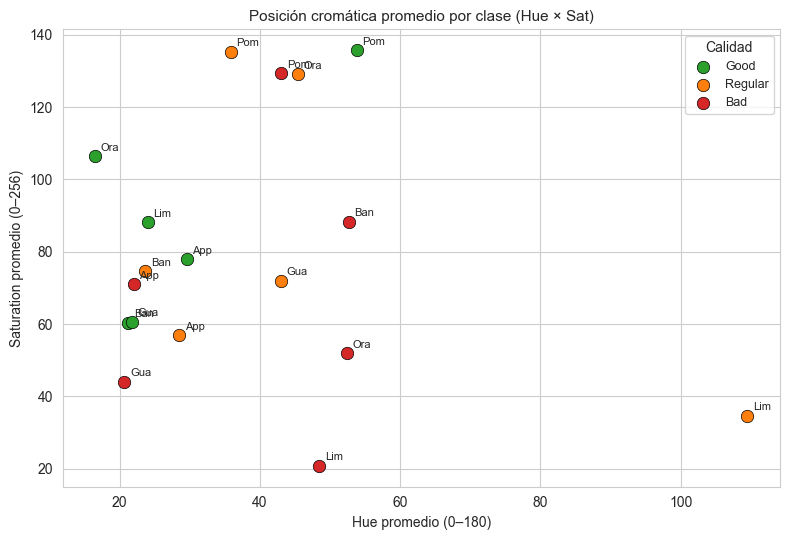

,class,fruit,quality,hue_mean,sat_mean,n
0,Apple_Bad,Apple,Bad,22.0,71.0,60
1,Apple_Good,Apple,Good,29.6,78.0,60
2,Apple_Regular,Apple,Regular,28.5,57.0,60
3,Banana_Bad,Banana,Bad,52.7,88.3,60
4,Banana_Good,Banana,Good,21.2,60.4,60
5,Banana_Regular,Banana,Regular,23.6,74.6,60
6,Guava_Bad,Guava,Bad,20.7,44.1,60
7,Guava_Good,Guava,Good,21.7,60.6,60
8,Guava_Regular,Guava,Regular,43.0,72.0,60
9,Lime_Bad,Lime,Bad,48.4,20.8,60


In [12]:
rows = []
for cls, (h, s, v, n) in hsv_avg.items():
    centers_h = np.linspace(2.5, 177.5, len(h))
    centers_s = np.linspace(4, 252, len(s))
    h_mean = np.average(centers_h, weights=h)
    s_mean = np.average(centers_s, weights=s)
    fruit, qual = cls.split("_")
    rows.append({"class": cls, "fruit": fruit, "quality": qual, "hue_mean": h_mean, "sat_mean": s_mean, "n": n})

hsv_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5.5))
for q in QUALITIES:
    sub = hsv_df[hsv_df["quality"] == q]
    ax.scatter(sub["hue_mean"], sub["sat_mean"], s=80, c=QUALITY_COLORS[q], label=q, edgecolors="black", linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r["fruit"][:3], (r["hue_mean"], r["sat_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Hue promedio (0–180)")
ax.set_ylabel("Saturation promedio (0–256)")
ax.set_title("Posición cromática promedio por clase (Hue × Sat)")
ax.legend(title="Calidad")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_hue_sat_scatter.svg")
plt.show()
hsv_df.sort_values(["fruit", "quality"]).round(1)

## 6. Hallazgos clave (para el informe IEEE)

> Esta sección sintetiza los puntos importantes del EDA. Se reproduce en `outputs/eda_report.md` para alimentar el documento final.

### 6.1 Volumen y cobertura
- **9,515 imágenes** distribuidas en **18 clases** (6 frutas × 3 calidades), provenientes de la recolección compartida del curso (`Fruits/`).
- El dataset de Kaggle (`mixed_quality` y subconjuntos por fruta) queda como **base de referencia opcional** para evaluación de robustez (sec. 2.1 del enunciado).

### 6.2 Desbalanceo
- **Imbalance Ratio ≈ 14** (Pomegranate_Good ≈ 1585 vs Orange_Bad ≈ 111) → desbalanceo severo.
- Entropía normalizada por debajo del ideal (1.0) → no es uniforme.
- **Decisión preliminar:** aplicar `class_weight="balanced"` en ML tradicional y CNN. Evaluar augmentation diferenciada en clases minoritarias.

### 6.3 Heterogeneidad de tamaño
- Resolución mediana ≈ 495×434 px, con rango muy amplio (varias imágenes < 100 px y otras > 3000 px).
- **Decisión preliminar:** resize fijo a 224×224 para entrada del modelo (compatible con CNNs estándar) y eliminar imágenes < 64 px como outliers de calidad de captura.

### 6.4 Diferenciación cromática
- En el espacio HSV, las frutas se separan claramente por Hue (eje de especie).
- Saturation tiende a caer en las clases `Bad` para varias frutas (frutas magulladas pierden vivacidad cromática) → es una señal explotable por el modelo.

### 6.5 Riesgos identificados
- **Sesgo de fuente:** todo el dataset es recolección estudiantil; condiciones de captura no controladas (iluminación, ángulo, fondo).
- **Sesgo de clase:** Pomegranate domina; el modelo podría aprender "es granada" antes que "es de calidad baja".
- **Imágenes sospechosas:** thumbnails (< 100 px) y posibles duplicados (se aborda en preprocesamiento).


In [13]:
# Persistir el resumen como Markdown para el informe IEEE
report_path = REPO_ROOT / "outputs" / "eda_report.md"
report_path.parent.mkdir(parents=True, exist_ok=True)

lines = []
lines.append("# Reporte EDA — Fase 1 CRISP-DM\n")
lines.append("> Generado automáticamente desde `notebooks/01_comprension_datos.ipynb`.\n")
lines.append("> Proyecto: Clasificación de calidad de frutas — APO3 ICESI 2026-1.\n\n")

lines.append("## 1. Resumen ejecutivo\n\n")
lines.append(f"- **Imágenes totales:** {len(df):,}\n")
lines.append(f"- **Clases:** {df['class'].nunique()} (6 frutas × 3 calidades)\n")
lines.append(f"- **Fuentes:** {df['source'].value_counts().to_dict()}\n\n")

lines.append("## 2. Distribución de clases\n\n")
lines.append("| Clase | n | % |\n|---|---:|---:|\n")
for cls, n in df["class"].value_counts().sort_index().items():
    lines.append(f"| {cls} | {n} | {100*n/len(df):.2f}% |\n")

lines.append(f"\n**Imbalance Ratio:** {IR:.2f}  ")
lines.append(f"\n**Entropía normalizada:** {H_norm:.3f}  ")
lines.append(f"\n**Coef. de variación:** {CV:.2f}\n\n")

lines.append("## 3. Dimensiones de imagen\n\n")
lines.append("| Estadístico | Width | Height |\n|---|---:|---:|\n")
lines.append(f"| min | {df['width'].min()} | {df['height'].min()} |\n")
lines.append(f"| p25 | {df['width'].quantile(.25):.0f} | {df['height'].quantile(.25):.0f} |\n")
lines.append(f"| mediana | {df['width'].median():.0f} | {df['height'].median():.0f} |\n")
lines.append(f"| p75 | {df['width'].quantile(.75):.0f} | {df['height'].quantile(.75):.0f} |\n")
lines.append(f"| max | {df['width'].max()} | {df['height'].max()} |\n\n")

lines.append("## 4. Hallazgos y decisiones para Fase 2 (preparación)\n\n")
lines.append(f"1. **Desbalanceo severo (IR≈{IR:.1f})** → `class_weight='balanced'` + augmentation en minoritarias.\n")
lines.append("2. **Resolución heterogénea** → resize fijo a 224×224 + filtro de imágenes < 64 px.\n")
lines.append("3. **HSV discrimina especies (Hue) y calidades (Saturation)** → features HSV explícitos en ML tradicional.\n")
lines.append("4. **Sesgo de fuente y de clase** → splits estratificados por `class` y métricas por clase.\n\n")

lines.append("## 5. Figuras producidas\n\n")
lines.append("Las figuras vectoriales (SVG) están en `outputs/figures/eda/`:\n\n")
lines.append("- `01_distribucion_18_clases.svg` — bar chart de las 18 clases.\n")
lines.append("- `02_heatmap_fruta_calidad.svg` — tabla cruzada en heatmap.\n")
lines.append("- `03_porcentaje_vs_uniforme.svg` — desviación de la distribución uniforme.\n")
lines.append("- `04_size_distributions.svg` — histogramas de width, height, aspect.\n")
lines.append("- `05_muestras_grid.svg` — grid 6×3 de ejemplos visuales.\n")
lines.append("- `06_hsv_apple.svg`, `07_hsv_banana.svg` — histogramas HSV por calidad.\n")
lines.append("- `08_hue_sat_scatter.svg` — posición cromática promedio de cada clase.\n")

report_md = "".join(lines)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)
print(f"[OK] Reporte EDA guardado en: {report_path}")


[OK] Reporte EDA guardado en: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\outputs\eda_report.md


## 7. Próximos pasos (Fase 3 — Preparación)

1. **Limpieza:** filtrar imágenes < 64 px de lado y verificar posibles duplicados con hash perceptual.
2. **Resize y normalización:** 224×224 RGB, valores en [0, 1].
3. **Split estratificado por `class`** (las 18 clases): 70% train / 15% val / 15% test.
4. **Data augmentation con `albumentations`** (rotaciones, brillo, flips). Más fuerte en clases minoritarias.
5. **Extracción de features para ML tradicional:** histograma HSV (96 bins) + LBP + momentos de Hu (vector ≈ 141-D).

Estas decisiones se implementan y documentan en `notebooks/02_preparacion_datos.ipynb`.
